# 9 — Stage 1 Results (E1 + E2 + E3 + E6 + E7)

**E1 — Modularity:** Do universal circuits survive marginalization?

**E2 — Concept vs Token:** What fraction of a concept's circuit is concept-only?

**E3 — Meta-circuits:** Do hypothesised groups share concept-only neurons?

**E6 — Layer dynamics:** What flow types do concepts exhibit?

**E7 — Cross-language:** Do equivalent Python/Rust concepts share neurons?

E1/E2 computed from neuron list CSVs. E3/E6/E7 loaded from experiment notebook outputs.

In [1]:
# Cell 1 – Configuration
import subprocess, sys, os
for pkg in ["numpy", "pandas", "matplotlib", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

MODELS = ["QW", "DS"]
MODEL_CONFIGS = {
    "QW": {"id": "Qwen/Qwen2.5-Coder-7B",                "n_layers": 28, "mlp_dim": 3584},
    "DS": {"id": "deepseek-ai/deepseek-coder-6.7b-base",  "n_layers": 32, "mlp_dim": 4096},
}
LANGS = ["P", "R"]
LANG_LABELS = {"P": "Python", "R": "Rust"}
MODEL_LABELS = {"QW": "Qwen", "DS": "DeepSeek"}

EPSILONS = ["0.001", "0.1", "0.5"]
CONSISTENCIES = ["0.2", "0.5", "0.8"]
N_LAYERS = max(c["n_layers"] for c in MODEL_CONFIGS.values())

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import shutil
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)
    DATA_DIR = Path("/content/drive/MyDrive/DATA/New-Atlas")
else:
    DATA_DIR = Path("/Users/piotrwilam/Data/New-Atlas")

print(f"Data: {DATA_DIR}")

Data: /Users/piotrwilam/Data/New-Atlas


In [2]:
# Cell 2 – Classification functions & load data

PYTHON_MODULAR = {"ast__Import", "ast__Break", "ast__Pass",
                  "ast__ImportFrom", "ast__Continue", "ast__Assert"}
RUST_MODULAR = {"rust__Use", "rust__Mod", "rust__Break", "rust__Continue",
                "rust__Return", "rust__Unsafe", "rust__Await"}
RUST_CONSTRUCTS = {
    "rust__For", "rust__While", "rust__Loop", "rust__If", "rust__Match",
    "rust__Fn", "rust__Closure", "rust__Let", "rust__LetMut", "rust__Const",
    "rust__Static", "rust__Struct", "rust__Enum", "rust__TypeAlias",
    "rust__Impl", "rust__Trait", "rust__Use", "rust__Mod",
    "rust__Return", "rust__Break", "rust__Continue",
    "rust__Async", "rust__Await", "rust__Unsafe",
    "rust__Ref", "rust__RefMut", "rust__Deref", "rust__Lifetime",
    "rust__Macro", "rust__Attribute", "rust__QuestionMark",
}

def classify(obj, lang):
    if lang == "P":
        if obj.startswith("builtin__"):
            return "Builtin"
        if obj in PYTHON_MODULAR:
            return "Modular"
        return "Non-modular"
    else:
        if obj in RUST_MODULAR:
            return "Modular"
        if obj in RUST_CONSTRUCTS:
            return "Non-modular"
        return "Object"


def load_neuron_list(data_dir, prefix, eps, cons, obj_type="both"):
    """Load neuron list CSV, concatenating part1+part2 split files."""
    # Try split files first (new format)
    p1 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part1_{obj_type}.csv")
    p2 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part2_{obj_type}.csv")
    if os.path.exists(p1) and os.path.exists(p2):
        return pd.concat([pd.read_csv(p1), pd.read_csv(p2)], ignore_index=True)
    # Fallback: try all_layers (old format)
    old = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_all_layers_{obj_type}.csv")
    if os.path.exists(old):
        return pd.read_csv(old)
    return None

frames = {}  # (lang, model, eps, cons) -> DataFrame

for lang in LANGS:
    for model in MODELS:
        prefix = f"{lang}_{model}_"
        for eps in EPSILONS:
            for cons in CONSISTENCIES:
                df = load_neuron_list(str(DATA_DIR), prefix, eps, cons)
                if df is None:
                    continue
                df["circuit_size"] = df["n_concept_only"] + df["n_both"]
                df["concept_fraction"] = (df["n_concept_only"] / df["circuit_size"]).replace([np.inf], 0).fillna(0)
                df["group"] = df["object"].apply(lambda o: classify(o, lang))
                frames[(lang, model, eps, cons)] = df

print(f"Loaded {len(frames)} neuron list files")
for key in sorted(frames.keys()):
    print(f"  {key[0]}_{key[1]} eps={key[2]} cons={key[3]}: {len(frames[key])} rows")

Loaded 18 neuron list files
  P_QW eps=0.001 cons=0.2: 1624 rows
  P_QW eps=0.001 cons=0.5: 1624 rows
  P_QW eps=0.001 cons=0.8: 1624 rows
  P_QW eps=0.1 cons=0.2: 1624 rows
  P_QW eps=0.1 cons=0.5: 1624 rows
  P_QW eps=0.1 cons=0.8: 1624 rows
  P_QW eps=0.5 cons=0.2: 1624 rows
  P_QW eps=0.5 cons=0.5: 1624 rows
  P_QW eps=0.5 cons=0.8: 1624 rows
  R_QW eps=0.001 cons=0.2: 1596 rows
  R_QW eps=0.001 cons=0.5: 1596 rows
  R_QW eps=0.001 cons=0.8: 1596 rows
  R_QW eps=0.1 cons=0.2: 1596 rows
  R_QW eps=0.1 cons=0.5: 1596 rows
  R_QW eps=0.1 cons=0.8: 1596 rows
  R_QW eps=0.5 cons=0.2: 1596 rows
  R_QW eps=0.5 cons=0.5: 1596 rows
  R_QW eps=0.5 cons=0.8: 1596 rows


In [3]:
# Cell 3 – E1: Modularity — Circuit survival after marginalization
#
# A concept's universal circuit is the intersection of its pair circuits
# across all pairings. If the circuit survives (size > 0), the concept
# has a modular representation. Circuit size = |concept_only| + |both|.

print("E1: MODULARITY — Circuit survival after marginalization")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"

        # Use a representative setting
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            print(f"\n--- {label}: missing (eps=0.5, cons=0.8) ---")
            continue

        print(f"\n--- {label} (eps=0.5, cons=0.8) ---")

        # Per-object: mean circuit size across layers
        obj_summary = (df.groupby(["object", "group"])
                       .agg(mean_circuit_size=("circuit_size", "mean"),
                            max_circuit_size=("circuit_size", "max"),
                            nonzero_layers=("circuit_size", lambda x: (x > 0).sum()))
                       .reset_index()
                       .sort_values("mean_circuit_size", ascending=False))

        # Survival rate: fraction of objects with circuit_size > 0 at any layer
        n_objects = obj_summary["object"].nunique()
        n_surviving = (obj_summary["max_circuit_size"] > 0).sum()
        print(f"  Objects with surviving circuit: {n_surviving}/{n_objects} ({100*n_surviving/n_objects:.0f}%)")

        # Per-group summary
        for group in sorted(obj_summary["group"].unique()):
            gsub = obj_summary[obj_summary["group"] == group]
            n = len(gsub)
            surv = (gsub["max_circuit_size"] > 0).sum()
            mean_sz = gsub["mean_circuit_size"].mean()
            mean_layers = gsub["nonzero_layers"].mean()
            print(f"  {group:15s}  objects={n:3d}  surviving={surv:3d} ({100*surv/n:.0f}%)  "
                  f"mean_size={mean_sz:.1f}  mean_active_layers={mean_layers:.1f}")

        # Top 10 by circuit size
        print(f"\n  Top 10 by mean circuit size:")
        for _, r in obj_summary.head(10).iterrows():
            print(f"    {r['object']:30s} [{r['group']:15s}]  mean={r['mean_circuit_size']:.1f}  "
                  f"max={r['max_circuit_size']}  active_layers={r['nonzero_layers']}")

E1: MODULARITY — Circuit survival after marginalization

--- Python / Qwen (eps=0.5, cons=0.8) ---
  Objects with surviving circuit: 58/58 (100%)
  Builtin          objects= 34  surviving= 34 (100%)  mean_size=843.8  mean_active_layers=28.0
  Modular          objects=  6  surviving=  6 (100%)  mean_size=1279.9  mean_active_layers=28.0
  Non-modular      objects= 18  surviving= 18 (100%)  mean_size=891.8  mean_active_layers=28.0

  Top 10 by mean circuit size:
    ast__Pass                      [Modular        ]  mean=1337.4  max=3584  active_layers=28
    ast__Import                    [Modular        ]  mean=1312.9  max=3584  active_layers=28
    ast__Break                     [Modular        ]  mean=1276.3  max=3584  active_layers=28
    ast__ImportFrom                [Modular        ]  mean=1274.6  max=3584  active_layers=28
    ast__Assert                    [Modular        ]  mean=1258.6  max=3584  active_layers=28
    ast__Continue                  [Modular        ]  mean=1219.8 

In [4]:
# Cell 4 – E1: Circuit size across threshold grid

print("E1: Mean circuit size across parameter grid")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"
        print(f"\n--- {label} ---")

        rows = []
        for eps in EPSILONS:
            for cons in CONSISTENCIES:
                df = frames.get((lang, model, eps, cons))
                if df is None:
                    rows.append({"eps": eps, "cons": cons, "Mean circuit": "-", "Surviving %": "-"})
                    continue

                obj_max = df.groupby("object")["circuit_size"].max()
                n_surv = (obj_max > 0).sum()
                n_total = len(obj_max)
                mean_cs = df["circuit_size"].mean()

                rows.append({
                    "eps": eps, "cons": cons,
                    "Mean circuit": f"{mean_cs:.1f}",
                    "Surviving %": f"{100*n_surv/n_total:.0f}%",
                })

        display(pd.DataFrame(rows))

E1: Mean circuit size across parameter grid

--- Python / Qwen ---


,eps,cons,Mean circuit,Surviving %
0,0.001,0.2,3584.0,100%
1,0.001,0.5,3584.0,100%
2,0.001,0.8,3584.0,100%
3,0.1,0.2,3061.2,100%
4,0.1,0.5,3061.2,100%
5,0.1,0.8,3061.2,100%
6,0.5,0.2,903.8,100%
7,0.5,0.5,903.8,100%
8,0.5,0.8,903.8,100%



--- Rust / Qwen ---


,eps,cons,Mean circuit,Surviving %
0,0.001,0.2,3584.0,100%
1,0.001,0.5,3584.0,100%
2,0.001,0.8,3584.0,100%
3,0.1,0.2,3137.9,100%
4,0.1,0.5,3137.9,100%
5,0.1,0.8,3137.9,100%
6,0.5,0.2,952.0,100%
7,0.5,0.5,952.0,100%
8,0.5,0.8,952.0,100%


E1: Circuit size by layer


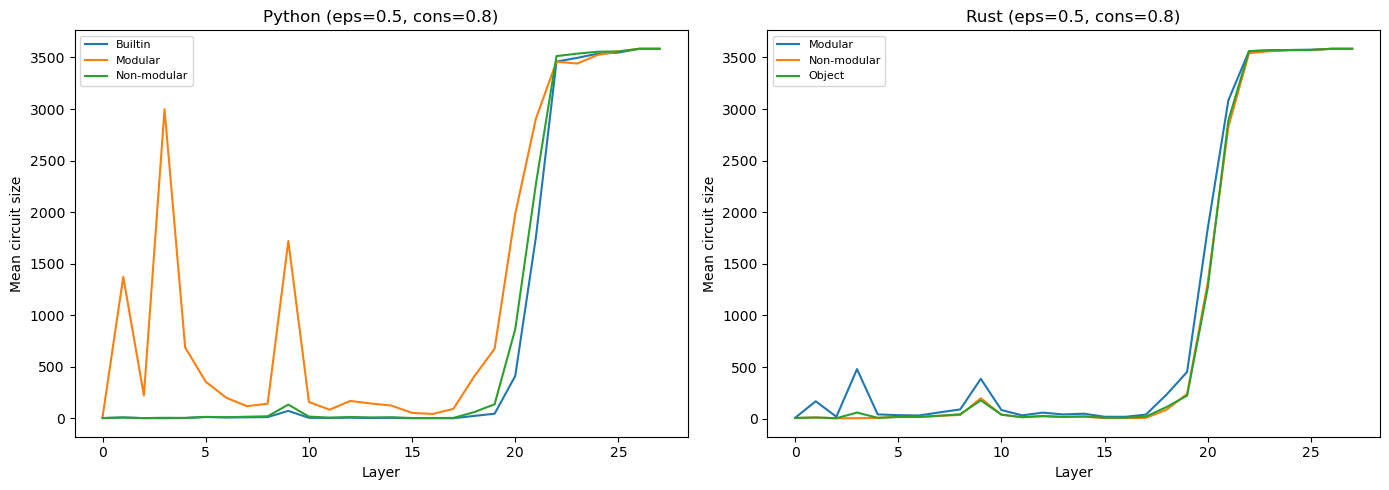

In [5]:
# Cell 5 – E1: Circuit size layer profile

print("E1: Circuit size by layer")
print("=" * 70)

fig, axes = plt.subplots(1, len(LANGS), figsize=(7*len(LANGS), 5), sharey=False)
if len(LANGS) == 1:
    axes = [axes]

for ax, lang in zip(axes, LANGS):
    for model in MODELS:
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            continue

        for group in sorted(df["group"].unique()):
            gsub = df[df["group"] == group]
            layer_means = gsub.groupby("layer")["circuit_size"].mean()
            ax.plot(layer_means.index, layer_means.values, label=group, linewidth=1.5)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean circuit size")
    ax.set_title(f"{LANG_LABELS[lang]} (eps=0.5, cons=0.8)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "9_E1_circuit_size_profile.png", dpi=150)
plt.show()

In [6]:
# Cell 6 – E2: Concept fraction grid (Table 1)

print("E2: Concept fraction across parameter grid")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"
        print(f"\n--- {label} ---")

        rows = []
        for eps in EPSILONS:
            for cons in CONSISTENCIES:
                df = frames.get((lang, model, eps, cons))
                if df is None:
                    rows.append({"eps": eps, "cons": cons,
                                 "Construct CF": "-", "Object CF": "-"})
                    continue

                concept_df = df[df["group"].isin(["Modular", "Non-modular"])]
                object_df = df[df["group"].isin(["Builtin", "Object"])]

                c_cf = (concept_df["n_concept_only"].sum() / concept_df["circuit_size"].sum()
                        if concept_df["circuit_size"].sum() > 0 else 0)
                o_cf = (object_df["n_concept_only"].sum() / object_df["circuit_size"].sum()
                        if object_df["circuit_size"].sum() > 0 else 0)

                rows.append({
                    "eps": eps, "cons": cons,
                    "Construct CF": f"{c_cf:.1%}",
                    "Object CF": f"{o_cf:.1%}",
                })

        display(pd.DataFrame(rows))

E2: Concept fraction across parameter grid

--- Python / Qwen ---


,eps,cons,Construct CF,Object CF
0,0.001,0.2,0.0%,0.0%
1,0.001,0.5,0.0%,0.0%
2,0.001,0.8,0.0%,0.0%
3,0.1,0.2,0.2%,0.0%
4,0.1,0.5,0.2%,0.0%
5,0.1,0.8,0.2%,0.0%
6,0.5,0.2,5.1%,1.0%
7,0.5,0.5,5.1%,1.0%
8,0.5,0.8,5.1%,1.0%



--- Rust / Qwen ---


,eps,cons,Construct CF,Object CF
0,0.001,0.2,0.0%,0.0%
1,0.001,0.5,0.0%,0.0%
2,0.001,0.8,0.0%,0.0%
3,0.1,0.2,0.8%,0.9%
4,0.1,0.5,0.8%,0.9%
5,0.1,0.8,0.8%,0.9%
6,0.5,0.2,10.7%,11.0%
7,0.5,0.5,10.7%,11.0%
8,0.5,0.8,10.7%,11.0%


In [7]:
# Cell 7 – E2: Neuron counts at mid-layer (Table 2)

MID_LAYER = 14
print(f"E2: Neuron counts at layer {MID_LAYER} (eps=0.5, cons=0.8)")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            print(f"\n--- {label}: missing ---")
            continue

        l_mid = df[df["layer"] == MID_LAYER]
        rows = []
        for group_name in sorted(l_mid["group"].unique()):
            g = l_mid[l_mid["group"] == group_name]
            c = g["n_concept_only"].sum()
            s = g["n_both"].sum()
            t = g["n_token_only"].sum()
            sz = c + s
            cf = c / sz if sz > 0 else 0
            rows.append({"Group": group_name, "Concept-only": c, "Shared": s,
                         "Token-only": t, "Circuit size": sz,
                         "Concept fraction": f"{cf:.1%}"})

        print(f"\n--- {label} ---")
        display(pd.DataFrame(rows))

E2: Neuron counts at layer 14 (eps=0.5, cons=0.8)

--- Python / Qwen ---


,Group,Concept-only,Shared,Token-only,Circuit size,Concept fraction
0,Builtin,23,192,3344,215,10.7%
1,Modular,439,311,325,750,58.5%
2,Non-modular,63,146,1665,209,30.1%



--- Rust / Qwen ---


,Group,Concept-only,Shared,Token-only,Circuit size,Concept fraction
0,Modular,165,119,1349,284,58.1%
1,Non-modular,135,144,3177,279,48.4%
2,Object,406,353,8454,759,53.5%


In [8]:
# Cell 8 – E2: Layer-by-layer concept fraction (Table 3)

print("E2: Layer-by-layer concept fraction (eps=0.5, cons=0.8)")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            print(f"\n--- {label}: missing ---")
            continue

        available_layers = sorted(df["layer"].unique())
        rows = []
        for group_label in sorted(df["group"].unique()):
            row = {"Group": group_label}
            for layer in available_layers:
                sub = df[(df["layer"] == layer) & (df["group"] == group_label)]
                c = sub["n_concept_only"].sum()
                sz = sub["circuit_size"].sum()
                cf = c / sz if sz > 0 else 0
                row[f"L{layer}"] = f"{cf:.1%}"
            rows.append(row)

        print(f"\n--- {label} ---")
        display(pd.DataFrame(rows))

E2: Layer-by-layer concept fraction (eps=0.5, cons=0.8)

--- Python / Qwen ---


,Group,L0,L1,L2,L3,L4,L5,L6,L7,L8,...,L18,L19,L20,L21,L22,L23,L24,L25,L26,L27
0,Builtin,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,1.5%,0.5%,3.3%,...,5.9%,9.8%,8.5%,5.5%,0.9%,0.9%,0.6%,0.2%,0.0%,0.0%
1,Modular,15.7%,28.6%,59.2%,6.4%,53.7%,52.3%,40.1%,41.4%,46.3%,...,52.9%,56.5%,23.5%,9.0%,1.1%,0.8%,0.7%,0.2%,0.0%,0.0%
2,Non-modular,0.0%,1.7%,1.6%,0.0%,0.0%,0.7%,2.3%,16.3%,17.7%,...,38.5%,43.9%,22.7%,8.5%,0.8%,0.8%,0.5%,0.2%,0.0%,0.0%



--- Rust / Qwen ---


,Group,L0,L1,L2,L3,L4,L5,L6,L7,L8,...,L18,L19,L20,L21,L22,L23,L24,L25,L26,L27
0,Modular,6.4%,0.6%,1.0%,0.0%,0.0%,8.5%,8.3%,54.4%,59.8%,...,63.7%,69.5%,52.0%,29.2%,11.7%,9.8%,6.1%,2.9%,0.3%,0.0%
1,Non-modular,4.6%,5.0%,4.0%,0.0%,3.8%,4.5%,12.8%,37.6%,41.0%,...,50.2%,62.2%,44.3%,27.1%,10.3%,7.6%,4.6%,2.0%,0.1%,0.0%
2,Object,3.1%,2.3%,1.6%,0.0%,3.4%,6.8%,12.4%,45.6%,51.7%,...,59.1%,64.8%,44.6%,29.2%,12.3%,9.8%,6.4%,3.2%,0.3%,0.0%


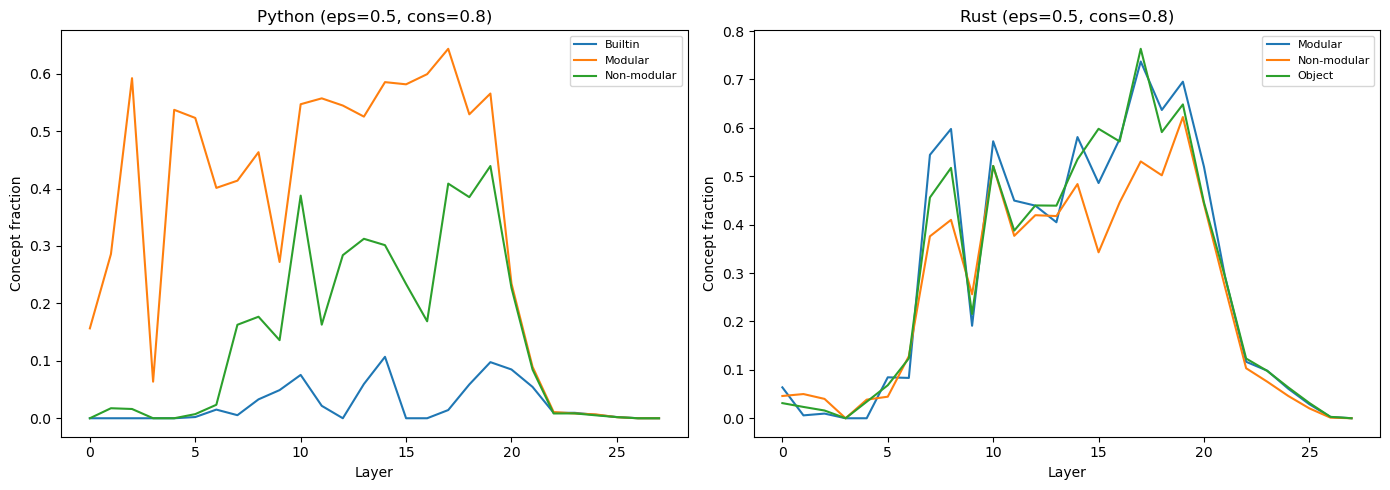

In [9]:
# Cell 9 – E2: Concept fraction layer profile (figure)

fig, axes = plt.subplots(1, len(LANGS), figsize=(7*len(LANGS), 5), sharey=False)
if len(LANGS) == 1:
    axes = [axes]

for ax, lang in zip(axes, LANGS):
    for model in MODELS:
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            continue

        for group in sorted(df["group"].unique()):
            gsub = df[df["group"] == group]
            available_layers = sorted(gsub["layer"].unique())
            layer_cf = []
            for lid in available_layers:
                lsub = gsub[gsub["layer"] == lid]
                c = lsub["n_concept_only"].sum()
                sz = lsub["circuit_size"].sum()
                layer_cf.append(c / sz if sz > 0 else 0)
            ax.plot(available_layers, layer_cf, label=group, linewidth=1.5)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Concept fraction")
    ax.set_title(f"{LANG_LABELS[lang]} (eps=0.5, cons=0.8)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "9_E2_concept_fraction_profile.png", dpi=150)
plt.show()

In [10]:
# Cell 10 – Per-object detail (eps=0.5, cons=0.8)

print("PER-OBJECT DETAIL (eps=0.5, cons=0.8)")
print("=" * 70)

for lang in LANGS:
    for model in MODELS:
        label = f"{LANG_LABELS[lang]} / {MODEL_LABELS[model]}"
        df = frames.get((lang, model, "0.5", "0.8"))
        if df is None:
            continue

        summary = (df.groupby(["object", "group"])
                   .agg(mean_concept_only=("n_concept_only", "mean"),
                        mean_both=("n_both", "mean"),
                        mean_circuit=("circuit_size", "mean"),
                        mean_cf=("concept_fraction", "mean"))
                   .reset_index()
                   .sort_values("mean_cf", ascending=False))

        print(f"\n--- {label} ---")
        display(summary.head(30))

PER-OBJECT DETAIL (eps=0.5, cons=0.8)

--- Python / Qwen ---


,object,group,mean_concept_only,mean_both,mean_circuit,mean_cf
13,ast__ImportFrom,Modular,212.892857,1061.750000,1274.642857,0.478239
12,ast__Import,Modular,152.928571,1159.964286,1312.892857,0.378769
0,ast__Assert,Modular,132.500000,1126.107143,1258.607143,0.349111
20,ast__While,Non-modular,60.607143,929.642857,990.250000,0.276609
6,ast__Continue,Modular,109.250000,1110.535714,1219.785714,0.246743
17,ast__Raise,Non-modular,43.464286,922.428571,965.892857,0.230265
19,ast__Try,Non-modular,44.892857,924.678571,969.571429,0.224697
4,ast__Break,Modular,114.928571,1161.357143,1276.285714,0.224298
16,ast__Pass,Modular,102.785714,1234.642857,1337.428571,0.207718
21,ast__With,Non-modular,51.535714,852.285714,903.821429,0.103055



--- Rust / Qwen ---


,object,group,mean_concept_only,mean_both,mean_circuit,mean_cf
11,rust__Crate,Object,298.250000,863.000000,1161.250000,0.417912
47,rust__Super,Object,302.464286,959.000000,1261.464286,0.408996
31,rust__Match,Non-modular,172.750000,843.250000,1016.000000,0.359746
5,rust__Break,Modular,117.821429,870.857143,988.678571,0.342214
42,rust__Self,Object,227.428571,718.428571,945.857143,0.337450
30,rust__Loop,Non-modular,129.107143,838.285714,967.392857,0.329126
55,rust__While,Non-modular,106.964286,867.964286,974.928571,0.328568
20,rust__For,Non-modular,197.035714,768.678571,965.714286,0.318780
41,rust__Return,Modular,184.571429,749.750000,934.321429,0.304701
25,rust__If,Non-modular,128.714286,814.714286,943.428571,0.304530


In [11]:
# Cell 11 – E3: Meta-circuits summary

print("E3: META-CIRCUITS — Group structure")
print("=" * 70)

e3_path = DATA_DIR / "7_E3_meta_circuit_results.csv"
if e3_path.exists() and e3_path.stat().st_size > 10:
    df_e3 = pd.read_csv(e3_path)
    print(f"Loaded: {len(df_e3)} rows")

    # Significant groups per language/model
    for (lang, model), sub in df_e3.groupby(["lang", "model"]):
        label = f"{LANG_LABELS.get(lang, lang)} / {MODEL_LABELS.get(model, model)}"
        print(f"\n--- {label} ---")
        sig = sub[sub["p_value"] < 0.05]
        print(f"  Significant group/layer combos: {len(sig)} / {len(sub)}")

        # Best group at each layer
        group_summary = (sub.groupby("group")
                         .agg(max_sharing=("sharing_ratio", "max"),
                              mean_sharing=("sharing_ratio", "mean"),
                              n_sig=("p_value", lambda x: (x < 0.05).sum()),
                              peak_layer=("sharing_ratio", "idxmax"))
                         .reset_index())
        group_summary["peak_layer"] = group_summary["peak_layer"].map(lambda idx: df_e3.loc[idx, "layer"])
        group_summary = group_summary.sort_values("max_sharing", ascending=False)
        display(group_summary)
else:
    print("  Not available — run 7_E3_meta_circuits first.")


E3: META-CIRCUITS — Group structure
Loaded: 256 rows

--- Python / Qwen ---
  Significant group/layer combos: 15 / 160


,group,max_sharing,mean_sharing,n_sig,peak_layer
1,Error handling,1.000000,0.116555,4,1
3,Iteration,1.000000,0.243300,2,1
2,Function def,1.000000,0.157705,0,6
4,Module import,1.000000,0.296658,7,22
0,Atomicity,0.005882,0.000464,2,7



--- Rust / Qwen ---
  Significant group/layer combos: 18 / 96


,group,max_sharing,mean_sharing,n_sig,peak_layer
0,Branching,1.0,0.237401,5,0
1,Iteration,1.0,0.173931,6,0
2,Loop control,1.0,0.195041,7,1


In [12]:
# Cell 12 – E6: Layer dynamics summary

print("E6: LAYER DYNAMICS — Flow type classification")
print("=" * 70)

e6_path = DATA_DIR / "7_E6_flow_type_assignments.csv"
if e6_path.exists() and e6_path.stat().st_size > 10:
    df_e6 = pd.read_csv(e6_path)
    print(f"Loaded: {len(df_e6)} rows")

    for (lang, model), sub in df_e6.groupby(["lang", "model"]):
        label = f"{LANG_LABELS.get(lang, lang)} / {MODEL_LABELS.get(model, model)}"
        print(f"\n--- {label} ---")

        # Flow type distribution
        dist = sub["flow_type"].value_counts()
        for ft, count in dist.items():
            print(f"  {ft:20s} {count:3d} concepts")

        # Top concepts per flow type
        for ft in dist.index[:3]:
            concepts = sub[sub["flow_type"] == ft]["concept"].tolist()[:5]
            short = [c.split("__")[1] if "__" in c else c for c in concepts]
            print(f"    {ft} examples: {', '.join(short)}")
else:
    print("  Not available — run 7_E6_layer_dynamics first.")


E6: LAYER DYNAMICS — Flow type classification
Loaded: 181 rows

--- Python / Qwen ---
  late_emergence        95 concepts
  two_phase              7 concepts
  unclassified           4 concepts
    late_emergence examples: AnnAssign, Assign, AsyncFor, AsyncFunctionDef, AsyncWith
    two_phase examples: Assert, Break, Continue, Import, ImportFrom
    unclassified examples: AugAssign, BinOp, Set, UnaryOp

--- Rust / Qwen ---
  late_emergence        71 concepts
  unclassified           2 concepts
  two_phase              2 concepts
    late_emergence examples: Arc, As, Async, Await, Box
    unclassified examples: Crate, TypeAlias
    two_phase examples: Super, Use


In [13]:
# Cell 13 – E7: Cross-language sharing summary

print("E7: CROSS-LANGUAGE — Neuron sharing between Python and Rust")
print("=" * 70)

e7_path = DATA_DIR / "7_E7_cross_language_results.csv"
if e7_path.exists() and e7_path.stat().st_size > 10:
    df_e7 = pd.read_csv(e7_path)
    print(f"Loaded: {len(df_e7)} rows")

    # Mean sharing per equivalence class
    mean_sharing = (df_e7.groupby(["model", "equivalence_class"])["sharing_fraction"]
                    .mean().reset_index()
                    .sort_values("sharing_fraction", ascending=False))

    for model, sub in mean_sharing.groupby("model"):
        label = MODEL_LABELS.get(model, model)
        print(f"\n--- {label} ---")
        for _, r in sub.iterrows():
            marker = "*" if r["sharing_fraction"] > 0.10 else " "
            print(f"  {marker} {r['equivalence_class']:20s} sharing={r['sharing_fraction']:.1%}")

        above_10 = (sub["sharing_fraction"] > 0.10).sum()
        print(f"\n  H6 test: {above_10}/{len(sub)} equivalence classes > 10% sharing")
else:
    print("  Not available — run 7_E7_cross_language first.")


E7: CROSS-LANGUAGE — Neuron sharing between Python and Rust
Loaded: 224 rows

--- Qwen ---
  * Iteration            sharing=34.0%
  * Loop control         sharing=28.9%
  * Branching            sharing=27.0%
  * Return               sharing=17.7%
  * Type def             sharing=14.6%
  * Module import        sharing=12.9%
    Function def         sharing=3.8%

  H6 test: 6/7 equivalence classes > 10% sharing


In [14]:
# Cell 14 – Save

# Save per-combo summaries
for (lang, model, eps, cons), df in frames.items():
    summary = (df.groupby(["object", "group"])
               .agg(mean_concept_only=("n_concept_only", "mean"),
                    mean_both=("n_both", "mean"),
                    mean_circuit=("circuit_size", "mean"),
                    mean_cf=("concept_fraction", "mean"))
               .reset_index())
    fname = f"9_results_{lang}_{model}_eps{eps}_cons{cons}.csv"
    summary.to_csv(DATA_DIR / fname, index=False)

print(f"Saved {len(frames)} summary CSVs")
print("\n9_results_stage1 complete.")

Saved 18 summary CSVs

9_results_stage1 complete.
